<a href="https://colab.research.google.com/github/JordanTerwilliger/Intro-to-Deep-Learning/blob/main/HW2/HW2_LanguageProcessing_RNN_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import requests

from torch import nn
from torch import functional as F
from torch import optim

!pip install torchinfo

import matplotlib.pyplot as plt


from torchinfo import summary

In [2]:
torch.manual_seed(1)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


#hyperparameters
lr = 0.01
epochs = 300
input_lengths = [10,20,30]
hidden_size = 100

device

device(type='cpu')

In [3]:
text_sequence = "Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text."

In [4]:
# We need to convert this text into a list of sorted indices for

sorted_text = list(sorted(set(text_sequence)))
print(sorted_text)

ix_to_char = {i: ch for i,ch in enumerate(sorted_text)}
print(ix_to_char)

char_to_ix = {ch: i for i, ch in enumerate(sorted_text)}

[' ', '(', ')', ',', '-', '.', 'A', 'I', 'L', 'N', 'P', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x']
{0: ' ', 1: '(', 2: ')', 3: ',', 4: '-', 5: '.', 6: 'A', 7: 'I', 8: 'L', 9: 'N', 10: 'P', 11: 'T', 12: 'a', 13: 'b', 14: 'c', 15: 'd', 16: 'e', 17: 'f', 18: 'g', 19: 'h', 20: 'i', 21: 'k', 22: 'l', 23: 'm', 24: 'n', 25: 'o', 26: 'p', 27: 'q', 28: 'r', 29: 's', 30: 't', 31: 'u', 32: 'v', 33: 'x'}


In [5]:
#Create Model
class RNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(RNN, self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.rnn = nn.RNN(input_size = hidden_size, hidden_size=hidden_size, batch_first = True)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)


  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.rnn(embedded)
    output = self.fc1(output[:, -1, :])
    return output

In [6]:
model = RNN(len(sorted_text), hidden_size, len(sorted_text)).to(device)
criterion = nn.CrossEntropyLoss()
optim = optim.SGD(model.parameters(), lr = lr)

In [7]:
#Splitting into train and test datasets
from sklearn.model_selection import train_test_split
def preprocess_text(text, sequence_length):
    # Preparing the dataset
    max_length = sequence_length  # Maximum length of input sequences
    X = []
    y = []
    for i in range(len(text) - max_length):
        sequence = text[i:i + max_length]
        label = text[i + max_length]
        X.append([char_to_ix[char] for char in sequence])
        y.append(char_to_ix[label])

    X = np.array(X)
    y = np.array(y)

    # Splitting the dataset into training and validation sets
    return train_test_split(X, y, test_size=0.2, random_state=1)

In [8]:
def createPlot(sequence_length):
  plt.figure(figsize=(12, 5))

  # Plot Loss
  plt.subplot(1, 2, 1)
  plt.plot(train_loss_list, label='Train Loss')
  plt.plot(val_loss_list, label='Val Loss')
  plt.title(f'Loss Curves Sequence Length:{sequence_length}')
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()

  # Plot Accuracy
  plt.subplot(1, 2, 2)
  plt.plot(val_accuracy_list, label='Val Accuracy')
  plt.title(f'Validation Accuracy Sequence Length:{sequence_length}')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy (%)')
  plt.legend()

  plt.show()

Epoch 0, Loss: 3.5608, Val Accuracy: 0.0519, Val Loss: 3.5379
Epoch 100, Loss: 3.1175, Val Accuracy: 0.1688, Val Loss: 3.2566
Epoch 200, Loss: 2.7302, Val Accuracy: 0.1948, Val Loss: 3.0115


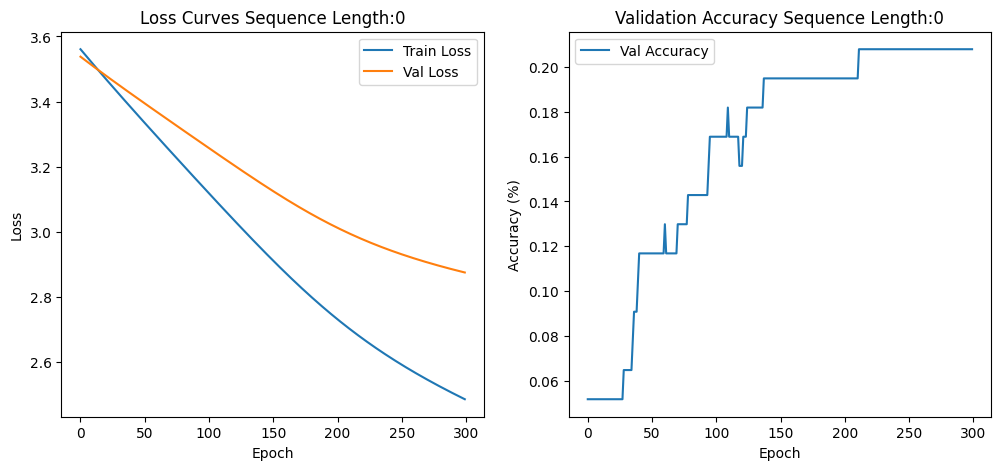

Epoch 0, Loss: 2.5749, Val Accuracy: 0.3200, Val Loss: 2.5020
Epoch 100, Loss: 2.3927, Val Accuracy: 0.3467, Val Loss: 2.4372
Epoch 200, Loss: 2.2450, Val Accuracy: 0.3067, Val Loss: 2.3894


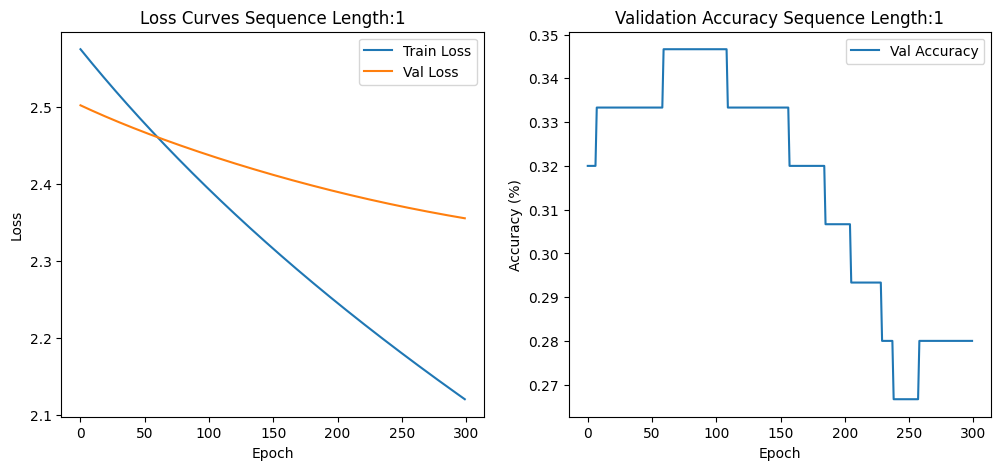

Epoch 0, Loss: 2.1764, Val Accuracy: 0.3562, Val Loss: 2.1861
Epoch 100, Loss: 2.0255, Val Accuracy: 0.3562, Val Loss: 2.2698
Epoch 200, Loss: 1.9059, Val Accuracy: 0.3425, Val Loss: 2.3288


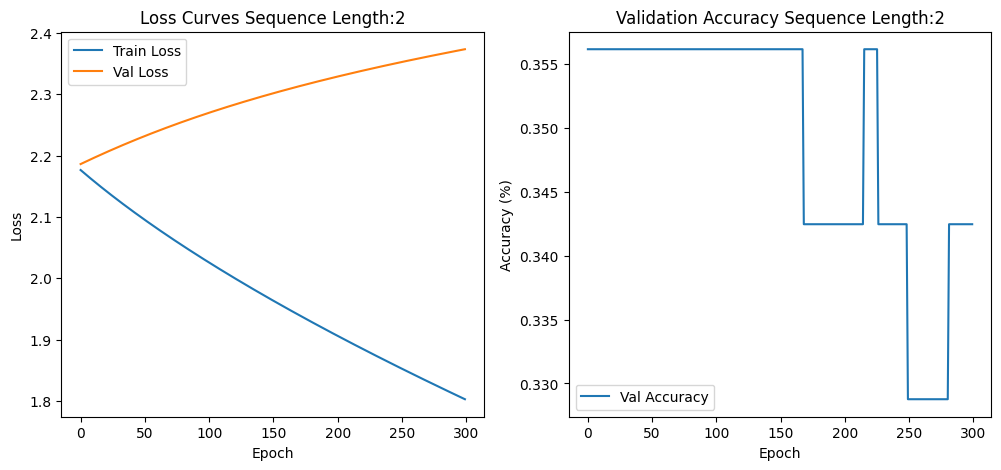

In [9]:


##Data Preprocessing and converting to tensor
for i, input_length in enumerate(input_lengths):
  X_train, X_val, y_train, y_val = preprocess_text(text_sequence, input_length)

  X_train = torch.tensor(X_train, dtype=torch.long).to(device)
  y_train = torch.tensor(y_train, dtype=torch.long).to(device)
  X_val = torch.tensor(X_val, dtype=torch.long).to(device)
  y_val = torch.tensor(y_val, dtype=torch.long).to(device)




  ###This is where training begins
  #Lists for storing loss and validation values
  train_loss_list = []
  val_loss_list = []
  val_accuracy_list = []


  #Create a new training loop for each input_length
  for epoch in range(epochs):
    model.train()

    optim.zero_grad()
    y_pred = model(X_train)  # Forward pass
    loss = criterion(y_pred, y_train)  # Compute loss
    loss.backward()  # Backward pass
    optim.step()  # Update model parameters

    train_loss_list.append(loss.item()) #Take this epoch's training loss and add it
                                        #to the training loss list (of all epochs)


    #Here is where we evaluate the model on the current epoch
    model.eval()
    with torch.no_grad():
      val_output = model(X_val) # Take test dataset and run it through this epoch's model

      val_loss = criterion(val_output, y_val) #Find the loss

      _, predicted = torch.max(val_output, 1) #Here we find what the output was (what letter)

      val_accuracy = (predicted == y_val).float().mean() #Here we take each answer from out model,
                                                         #compare it to the ground truth, and find how accurate we are

      val_loss_list.append(val_loss.item())
      val_accuracy_list.append(val_accuracy.item())

      if(epoch % 100) == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}, Val Accuracy: {val_accuracy.item():.4f}, Val Loss: {val_loss.item():.4f}')

  createPlot(sequence_length=i)



In [10]:
summary(model, input_size = (1,20), dtypes=[torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
RNN                                      [1, 34]                   --
├─Embedding: 1-1                         [1, 20, 100]              3,400
├─RNN: 1-2                               [1, 20, 100]              20,200
├─Linear: 1-3                            [1, 34]                   3,434
Total params: 27,034
Trainable params: 27,034
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.41
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.11
Estimated Total Size (MB): 0.14